<link rel="stylesheet" href="/mediapipe/site.css">

# Image classification model customization guide

<table align="left" class="buttons">
  <td>
    <a href="https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/customization/image_classifier.ipynb" target="_blank">
      <img src="https://developers.google.com/static/mediapipe/solutions/customization/colab-logo-32px_1920.png" alt="Colab logo"> Run in Colab
    </a>
  </td>

  <td>
    <a href="https://github.com/googlesamples/mediapipe/blob/main/examples/customization/image_classifier.ipynb" target="_blank">
      <img src="https://developers.google.com/static/mediapipe/solutions/customization/github-logo-32px_1920.png" alt="GitHub logo">
      View on GitHub
    </a>
  </td>
</table>

In [ ]:
#@title License information
# Copyright 2023 The MediaPipe Authors.
# Licensed under the Apache License, Version 2.0 (the "License");
#
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

The MediaPipe Model Maker package is a low-code solution for customizing on-device machine learning (ML) Models.

The MediaPipe image classification solution provides several models you can use immediately for machine learning (ML) in your application. However, if you need to classify images with content not covered by the provided models, you can customize any of the provided models with your own data and MediaPipe [Model Maker](https://developers.google.com/mediapipe/solutions/model_maker). This model modification tool rebuilds a portion of the model using data you provide. This method is faster than training a new model and can produce a model that is more useful for your specific application.

The following sections show you how to use Model Maker to retrain a pre-built model for image classification with your own data, which you can then use with the MediaPipe [Image Classifier](https://developers.google.com/mediapipe/solutions/vision/image_classifier). The example retrains a general purpose classification model to classify images of flowers.

This notebook shows the end-to-end process of customizing an ImageNet pretrained image classification model for recognizing flowers defined in a user customized flower dataset.

## Setup

This section describes key steps for setting up your development environment to retrain a model. These instructions describe how to update a model using [Google Colab](https://colab.research.google.com/), and you can also use Python in your own development environment. For general information on setting up your development environment for using MediaPipe, including platform version requirements, see the [Setup guide for Python](https://developers.google.com/mediapipe/solutions/setup_python).

To install the libraries for customizing a model, run the following commands:

In [1]:
%%python --version
%pip install --upgrade pip
%pip install --upgrade "setuptools==70.3.0" wheel
%pip install "mediapipe-model-maker==0.2.1.3"

Python 3.10.20


Use the following code to import the required Python classes:

In [2]:
## Importing required Libraries
import os
import contextlib
import io
import sys
import types
import platform
import logging
import warnings
import random
import shutil
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mediapipe as mp
import tensorflow as tf
import tensorflow_hub as hub
import keras
import tf_keras
from datetime import datetime
from absl import logging as absl_logging
from importlib import metadata
from importlib.metadata import PackageNotFoundError
from pathlib import Path
import inspect
from pathlib import Path


# Setting TensorFlow runtime flags before importing TensorFlow
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Setting warning filters
warnings.filterwarnings('ignore')

# Setting TensorFlow/absl logger levels to reduce noisy non-critical warnings
tf.get_logger().setLevel("ERROR")
logging.getLogger("tensorflow").setLevel(logging.ERROR)
absl_logging.set_verbosity(absl_logging.ERROR)

# Adding Keras 3 compatibility shim for packages expecting tf.keras.experimental
if not hasattr(tf.keras, "experimental"):
    tf.keras.experimental = types.SimpleNamespace()
if not hasattr(tf.keras.experimental, "CosineDecay"):
    tf.keras.experimental.CosineDecay = tf.keras.optimizers.schedules.CosineDecay

# Adding compatibility shim for legacy ModelCheckpoint(period=...) used by mediapipe-model-maker
_OriginalModelCheckpoint = tf.keras.callbacks.ModelCheckpoint

class PeriodCompatibleModelCheckpoint(_OriginalModelCheckpoint):
    def __init__(self, *args, period=None, **kwargs):
        # Setting legacy period behavior: save checkpoint every `period` epochs
        self._period = int(period) if period is not None else 1

        # Updating legacy checkpoint filepath to satisfy Keras 3 save_weights_only requirement
        if kwargs.get("save_weights_only") is True:
            if args:
                filepath = args[0]
                if isinstance(filepath, str) and not filepath.endswith(".weights.h5"):
                    filepath = f"{filepath}.weights.h5"
                    args = (filepath, *args[1:])
            elif "filepath" in kwargs:
                filepath = kwargs["filepath"]
                if isinstance(filepath, str) and not filepath.endswith(".weights.h5"):
                    kwargs["filepath"] = f"{filepath}.weights.h5"

        super().__init__(*args, **kwargs)

    def on_epoch_end(self, epoch, logs=None):
        if self._period <= 1 or ((epoch + 1) % self._period == 0):
            return super().on_epoch_end(epoch, logs)
        return None

tf.keras.callbacks.ModelCheckpoint = PeriodCompatibleModelCheckpoint
keras.callbacks.ModelCheckpoint = PeriodCompatibleModelCheckpoint

# Adding defensive patching for tf_keras callback namespace if present
try:
    tf_keras.callbacks.ModelCheckpoint = PeriodCompatibleModelCheckpoint
except Exception:
    pass

# Adding keras compatibility shims for packages expecting legacy keras.src modules
try:
    import tf_keras.src.engine as tfk_engine
    if "keras.src.engine" not in sys.modules:
        sys.modules["keras.src.engine"] = tfk_engine
except Exception:
    pass

try:
    import tf_keras.src.engine.base_layer_v1 as tfk_base_layer_v1
    if "keras.src.engine.base_layer_v1" not in sys.modules:
        sys.modules["keras.src.engine.base_layer_v1"] = tfk_base_layer_v1
except Exception:
    pass

try:
    import tf_keras.src.callbacks_v1 as tfk_callbacks_v1
    if "keras.src.callbacks_v1" not in sys.modules:
        sys.modules["keras.src.callbacks_v1"] = tfk_callbacks_v1
except Exception:
    pass

# Setting Apple Silicon optimizer workaround for faster training on M1/M2 with TF 2.11+
if platform.system() == "Darwin" and platform.machine() in {"arm64", "aarch64"}:
    try:
        tf.keras.optimizers.RMSprop = tf.keras.optimizers.legacy.RMSprop
    except Exception:
        pass

# Setting a shim package to avoid importing mediapipe_model_maker top-level __init__
mm_package_path = next(
    (os.path.join(path_item, "mediapipe_model_maker") for path_item in sys.path
     if os.path.isdir(os.path.join(path_item, "mediapipe_model_maker"))),
    None,
 )
if mm_package_path and "mediapipe_model_maker" not in sys.modules:
    mm_shim = types.ModuleType("mediapipe_model_maker")
    mm_shim.__path__ = [mm_package_path]
    sys.modules["mediapipe_model_maker"] = mm_shim

from mediapipe_model_maker.python.vision import image_classifier
from mediapipe_model_maker.python.core.utils import quantization
from mediapipe_model_maker.python.core.utils import model_util
from mediapipe_model_maker.python.vision.image_classifier import image_classifier as image_classifier_module

# Showing Versions
assert tf.__version__.startswith('2')
print(f"TensorFlow Version: {tf.__version__}")
print(f"MediaPipe Version: {mp.__version__}")
try:
    mm_version = metadata.version("mediapipe-model-maker")
except PackageNotFoundError:
    mm_version = "not installed"
print(f"MediaPipe Model Maker {mm_version}")
print(f"Keras Version: {keras.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Platform: {platform.system()} {platform.machine()}")
print(f"TF_USE_LEGACY_KERAS={os.environ.get('TF_USE_LEGACY_KERAS')}")


/Users/ben/conda/envs/dissertation-3.10/lib/python3.10/site-packages/google/api_core/_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow Version: 2.19.1
MediaPipe Version: 0.10.21
MediaPipe Model Maker 0.2.1.3
Keras Version: 3.12.1
Matplotlib Version: 3.10.8
Platform: Darwin arm64
TF_USE_LEGACY_KERAS=1


## Preparing data

Retraining a model for image classification requires a dataset that includes all kinds of items, or *classes*, that you want the completed model to be able to identify.

The dataset must be organized in a specific way. The dataset should be organized into folders, where each folder is named after the class of items it contains. For example, if you want to retrain a model to recognize different types of flowers, you could have a folder named `daisy` that contains images of daisies, and a folder named `rose` that contains images of roses.


In [10]:
# Setting data paths
# Updating these paths to point to your training data
NOTEBOOK_ROOT = Path.cwd()
PROJECT_ROOT = None

for root in [NOTEBOOK_ROOT, *NOTEBOOK_ROOT.parents]:
    if (root / "data").is_dir():
        PROJECT_ROOT = root
        break
    project_candidate = root / "project"
    if (project_candidate / "data").is_dir():
        PROJECT_ROOT = project_candidate
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_ROOT

DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_MODEL_PATH = DATA_ROOT / "models"
TRAIN_DATA_PATH = DATA_ROOT / "images/rebalanced_posture"
# Choose `VALIDATION_DATA_PATH` to be either `None` for splitting before training or a valid path to a validation dataset
VALIDATION_DATA_PATH = None
#VALIDATION_DATA_PATH = DATA_ROOT / "images/posture_val"

OUTPUT_MODEL_PATH.mkdir(parents=True, exist_ok=True)

print(f"Notebook root: {NOTEBOOK_ROOT}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Training data path: {TRAIN_DATA_PATH}")
print(f"Validation data path: {VALIDATION_DATA_PATH}")
print(f"Output model path: {OUTPUT_MODEL_PATH}")

Notebook root: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/code
Project root: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis
Training data path: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/images/rebalanced_posture
Validation data path: None
Output model path: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/models


The images need to be stored in a directory that contains several subdirectories, each corresponding to specific class labels `<image_path>/<label_name>/<image_names>.*`.

Augmentation is a common technique for improving the performance of a model when you have a limited dataset. It works by creating new training examples from your existing data by applying random transformations to the images, such as rotations, flips, and color adjustments. This can help the model learn to recognize patterns in the data that are invariant to these transformations, which can improve its ability to generalize to new data.

Here you can enable augmentation by setting the array for the classes with the fewest images or that are underperforming to increase the number of training examples for that class. This can help balance the dataset and improve the model's performance on that class.

In [11]:
# Setting per-class augmentation config as [class_name, multiplier, augmentation_ops]
AUGMENT_CLASS_MULTIPLIERS = [
    ["normal posture", 6, 2],
    ["slumped posture", 5, 2],
    ["tensed posture", 6, 2],
]

# Supplying manually defined folder with augmented images (in the same format as training data), to add to the training dataset instead of using built-in augmentation (comment out AUGMENT_CLASS_MULTIPLIERS if using this option): 
#AUGMENT_CLASS_MANUAL = None
AUGMENT_CLASS_MANUAL = DATA_ROOT / "images/rebalanced_overlay"

# Printing augmentation configuration for verification
print(f"AUGMENT_CLASS_MULTIPLIERS={AUGMENT_CLASS_MULTIPLIERS}")
print(f"AUGMENT_CLASS_MANUAL={AUGMENT_CLASS_MANUAL}")

AUGMENT_CLASS_MULTIPLIERS=[['normal posture', 6, 2], ['slumped posture', 5, 2], ['tensed posture', 6, 2]]
AUGMENT_CLASS_MANUAL=/Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/images/rebalanced_overlay


In [12]:
# Setting selected-class augmentation configuration
OVERSAMPLING_SEED = 42
VALIDATION_DATA_SLIT = 0.10  # Fraction of training data to use for validation if VALIDATION_DATA_PATH is not set


def _strip_aug_suffixes(path_name):
    suffixes = [
        "_oversampled",
        "_slumped_aug_only",
        "_selected_aug_only",
        "_manual_aug_only",
        "_selected_plus_manual_aug",
    ]
    changed = True
    base_name = path_name
    while changed:
        changed = False
        for suffix in suffixes:
            if base_name.endswith(suffix):
                base_name = base_name[: -len(suffix)]
                changed = True
    return base_name


def _resolve_train_source_dir(current_train_path):
    # Setting priority to the explicitly configured training path from the data-path cell
    if current_train_path.exists() and current_train_path.is_dir():
        return current_train_path

    base_name = _strip_aug_suffixes(current_train_path.name)
    fallback_from_current = current_train_path.parent / base_name

    preferred = [
        DATA_ROOT / "images" / "rebalanced_overlay",
        DATA_ROOT / "images" / "overlay",
    ]

    # Adding fallback candidates only if the configured training path does not exist
    candidates = [fallback_from_current, *preferred]

    seen = set()
    unique_candidates = []
    for candidate in candidates:
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate

    raise RuntimeError(
        "Could not resolve a valid training source directory. "
        f"Configured TRAIN_DATA_PATH: {current_train_path}. "
        f"Checked fallbacks: {[str(c) for c in unique_candidates]}"
    )


def _resolve_manual_augment_dir(manual_path):
    if manual_path is None:
        return None

    path_obj = Path(manual_path)
    if not path_obj.exists() or not path_obj.is_dir():
        raise RuntimeError(
            f"AUGMENT_CLASS_MANUAL points to a missing or invalid directory: {path_obj}"
        )

    return path_obj


def _parse_class_multiplier_config(raw_config):
    class_settings = {}

    if raw_config is None:
        return class_settings

    if not isinstance(raw_config, list):
        raise TypeError(
            "AUGMENT_CLASS_MULTIPLIERS must be a list of [class_name, multiplier] or "
            "[class_name, multiplier, augmentation_ops] entries"
        )

    for idx, item in enumerate(raw_config):
        if not isinstance(item, (list, tuple)) or len(item) not in (2, 3):
            raise ValueError(
                f"Invalid entry at index {idx}: {item}. Expected [class_name, multiplier] or "
                "[class_name, multiplier, augmentation_ops]"
            )

        class_name, multiplier = item[0], item[1]
        augmentation_ops = item[2] if len(item) == 3 else 3

        if not isinstance(class_name, str) or not class_name.strip():
            raise ValueError(f"Invalid class name at index {idx}: {class_name}")

        try:
            multiplier_value = float(multiplier)
        except (TypeError, ValueError):
            raise ValueError(f"Invalid multiplier for class '{class_name}': {multiplier}")

        if multiplier_value < 1.0:
            raise ValueError(
                f"Multiplier for class '{class_name}' must be >= 1.0, got {multiplier_value}"
            )

        try:
            augmentation_ops_value = int(augmentation_ops)
        except (TypeError, ValueError):
            raise ValueError(
                f"Invalid augmentation_ops for class '{class_name}': {augmentation_ops}"
            )

        if augmentation_ops_value < 1 or augmentation_ops_value > 5:
            raise ValueError(
                f"augmentation_ops for class '{class_name}' must be between 1 and 5, "
                f"got {augmentation_ops_value}"
            )

        class_settings[class_name.strip()] = {
            "multiplier": multiplier_value,
            "augmentation_ops": augmentation_ops_value,
        }

    return class_settings


TRAIN_DATA_PATH_ORIGINAL = _resolve_train_source_dir(TRAIN_DATA_PATH)
TRAIN_DATA_PATH_SELECTED_AUG = DATA_ROOT / "images" / f"{TRAIN_DATA_PATH_ORIGINAL.name}_selected_aug_only"
TRAIN_DATA_PATH_MANUAL_AUG = DATA_ROOT / "images" / f"{TRAIN_DATA_PATH_ORIGINAL.name}_manual_aug_only"
TRAIN_DATA_PATH_SELECTED_PLUS_MANUAL = (
    DATA_ROOT / "images" / f"{TRAIN_DATA_PATH_ORIGINAL.name}_selected_plus_manual_aug"
 )
CLASS_AUGMENT_MULTIPLIERS = _parse_class_multiplier_config(
    AUGMENT_CLASS_MULTIPLIERS if "AUGMENT_CLASS_MULTIPLIERS" in globals() else []
)
MANUAL_AUGMENT_DIR = _resolve_manual_augment_dir(
    globals().get("AUGMENT_CLASS_MANUAL", None)
 )


def _list_image_files(directory):
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
    files = []
    for entry in sorted(directory.iterdir()):
        if entry.is_file() and not entry.name.startswith(".") and entry.suffix.lower() in valid_ext:
            files.append(entry)
    return files


def _count_images_per_class(directory):
    class_counts = {}
    if not directory.exists():
        return class_counts

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            class_counts[class_dir.name] = len(_list_image_files(class_dir))
    return class_counts


def _copy_dataset_tree(src_root, dst_root):
    if dst_root.exists():
        shutil.rmtree(dst_root)
    dst_root.mkdir(parents=True, exist_ok=True)

    class_dirs = [d for d in sorted(src_root.iterdir()) if d.is_dir()]
    if not class_dirs:
        raise RuntimeError(f"No class directories found under: {src_root}")

    for class_dir in class_dirs:
        dst_class_dir = dst_root / class_dir.name
        dst_class_dir.mkdir(parents=True, exist_ok=True)
        for src_file in _list_image_files(class_dir):
            shutil.copy2(src_file, dst_class_dir / src_file.name)


def _augment_image_opencv(image_bgr, rng, augmentation_ops=3):
    h, w = image_bgr.shape[:2]

    def _op_flip(img):
        flip_mode = rng.choice([None, 1, 0])
        if flip_mode is None:
            return img
        return cv2.flip(img, flip_mode)

    def _op_affine(img):
        angle = rng.uniform(-12.0, 12.0)
        scale = rng.uniform(0.90, 1.10)
        tx = rng.uniform(-0.08 * w, 0.08 * w)
        ty = rng.uniform(-0.08 * h, 0.08 * h)
        shear = np.tan(np.deg2rad(rng.uniform(-8.0, 8.0)))

        m_rot = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle, scale)
        m_rot_3 = np.vstack([m_rot, [0.0, 0.0, 1.0]])
        m_shear = np.array([[1.0, shear, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]], dtype=np.float32)
        m_translate = np.array([[1.0, 0.0, tx], [0.0, 1.0, ty], [0.0, 0.0, 1.0]], dtype=np.float32)
        m_affine = (m_translate @ m_shear @ m_rot_3)[:2, :]
        return cv2.warpAffine(
            img,
            m_affine,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101,
        )

    def _op_crop_resize(img):
        crop_ratio = rng.uniform(0.80, 1.00)
        crop_w = max(1, int(w * crop_ratio))
        crop_h = max(1, int(h * crop_ratio))
        x0 = rng.randint(0, max(0, w - crop_w))
        y0 = rng.randint(0, max(0, h - crop_h))
        cropped = img[y0 : y0 + crop_h, x0 : x0 + crop_w]
        return cv2.resize(cropped, (w, h), interpolation=cv2.INTER_LINEAR)

    def _op_hsv_jitter(img):
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[..., 0] = (hsv[..., 0] + rng.uniform(-10.0, 10.0)) % 180.0
        hsv[..., 1] = np.clip(hsv[..., 1] * rng.uniform(0.75, 1.25), 0.0, 255.0)
        hsv[..., 2] = np.clip(hsv[..., 2] * rng.uniform(0.75, 1.25), 0.0, 255.0)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    def _op_intensity(img):
        alpha = rng.uniform(0.85, 1.20)
        beta = rng.uniform(-20.0, 20.0)
        return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    def _op_gaussian_noise(img):
        sigma = rng.uniform(5.0, 18.0)
        noise = np.zeros_like(img, dtype=np.int16)
        cv2.randn(noise, 0, sigma)
        return np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    def _op_random_erasing(img):
        erase_area = rng.uniform(0.02, 0.12) * h * w
        erase_aspect = rng.uniform(0.4, 2.5)
        erase_h = int(np.sqrt(erase_area / erase_aspect))
        erase_w = int(np.sqrt(erase_area * erase_aspect))
        erase_h = min(max(1, erase_h), h)
        erase_w = min(max(1, erase_w), w)
        ex = rng.randint(0, max(0, w - erase_w))
        ey = rng.randint(0, max(0, h - erase_h))
        fill_value = int(rng.randint(0, 255))
        output = img.copy()
        output[ey : ey + erase_h, ex : ex + erase_w] = (fill_value, fill_value, fill_value)
        return output

    operations = [
        _op_flip,
        _op_affine,
        _op_crop_resize,
        _op_hsv_jitter,
        _op_intensity,
        _op_gaussian_noise,
        _op_random_erasing,
    ]

    ops_to_apply = max(1, min(5, int(augmentation_ops)))
    chosen_ops = rng.sample(operations, k=min(ops_to_apply, len(operations)))

    augmented = image_bgr
    for operation in chosen_ops:
        augmented = operation(augmented)

    return augmented


def _build_selected_class_augmented_dataset(src_root, dst_root, class_settings, seed):
    rng = random.Random(seed)

    # Setting clean destination for deterministic rebuilds
    if dst_root.exists():
        shutil.rmtree(dst_root)
    dst_root.mkdir(parents=True, exist_ok=True)

    class_dirs = [d for d in sorted(src_root.iterdir()) if d.is_dir()]
    if not class_dirs:
        raise RuntimeError(f"No class directories found under: {src_root}")

    class_name_set = {class_dir.name for class_dir in class_dirs}
    missing = sorted(set(class_settings.keys()) - class_name_set)
    if missing:
        raise RuntimeError(f"Requested classes not found: {missing}")

    summary = {}
    for class_dir in class_dirs:
        class_name = class_dir.name
        dst_class_dir = dst_root / class_name
        dst_class_dir.mkdir(parents=True, exist_ok=True)

        source_files = _list_image_files(class_dir)
        for src_file in source_files:
            shutil.copy2(src_file, dst_class_dir / src_file.name)

        if class_name not in class_settings:
            summary[class_name] = {
                "original": len(source_files),
                "requested_added": 0,
                "actual_added": 0,
                "final": len(source_files),
                "multiplier": 1.0,
                "augmentation_ops": 0,
            }
            continue

        if not source_files:
            raise RuntimeError(f"No images found for class: {class_name}")

        settings = class_settings[class_name]
        multiplier = settings["multiplier"]
        augmentation_ops = settings["augmentation_ops"]
        extra_needed = max(0, int(round(len(source_files) * (multiplier - 1.0))))

        written = 0
        for idx in range(extra_needed):
            src_file = rng.choice(source_files)
            image_bgr = cv2.imread(str(src_file), cv2.IMREAD_COLOR)
            if image_bgr is None:
                continue

            aug_bgr = _augment_image_opencv(image_bgr, rng, augmentation_ops=augmentation_ops)
            out_name = f"{src_file.stem}__aug{idx:05d}.jpg"
            ok = cv2.imwrite(str(dst_class_dir / out_name), aug_bgr)
            if ok:
                written += 1

        summary[class_name] = {
            "original": len(source_files),
            "requested_added": extra_needed,
            "actual_added": written,
            "final": len(source_files) + written,
            "multiplier": multiplier,
            "augmentation_ops": augmentation_ops,
        }

    return summary


def _merge_manual_augment_dataset(manual_root, dst_root):
    if manual_root is None:
        return {}

    class_dirs = [d for d in sorted(manual_root.iterdir()) if d.is_dir()]
    if not class_dirs:
        raise RuntimeError(f"No class directories found under AUGMENT_CLASS_MANUAL: {manual_root}")

    summary = {}
    for class_dir in class_dirs:
        class_name = class_dir.name
        src_files = _list_image_files(class_dir)
        dst_class_dir = dst_root / class_name
        dst_class_dir.mkdir(parents=True, exist_ok=True)

        added = 0
        skipped = 0
        for src_file in src_files:
            candidate_name = src_file.name
            target_file = dst_class_dir / candidate_name

            if target_file.exists():
                stem = src_file.stem
                suffix = src_file.suffix.lower()
                index = 1
                while target_file.exists():
                    candidate_name = f"{stem}__manual{index:03d}{suffix}"
                    target_file = dst_class_dir / candidate_name
                    index += 1

            try:
                shutil.copy2(src_file, target_file)
                added += 1
            except OSError:
                skipped += 1

        summary[class_name] = {
            "added": added,
            "skipped": skipped,
            "source_files": len(src_files),
        }

    return summary

print("You can now run the next cell to prepare the training dataset with the specified augmentation configuration. This may take some time depending on the size of your dataset and augmentation settings.")

You can now run the next cell to prepare the training dataset with the specified augmentation configuration. This may take some time depending on the size of your dataset and augmentation settings.


Creating a balanced dataset is important for training a model that performs well on all classes. If one class has significantly more examples than another, the model may become biased towards the majority class and perform poorly on the minority class. By using augmentation to increase the number of examples for the minority class, you can help balance the dataset and improve the model's performance on that class.

In [13]:
# Applying selected-class augmentation now so output is visible in this stage
active_train_path = TRAIN_DATA_PATH_ORIGINAL

if CLASS_AUGMENT_MULTIPLIERS:
    selected_summary = _build_selected_class_augmented_dataset(
        src_root=TRAIN_DATA_PATH_ORIGINAL,
        dst_root=TRAIN_DATA_PATH_SELECTED_AUG,
        class_settings=CLASS_AUGMENT_MULTIPLIERS,
        seed=OVERSAMPLING_SEED,
    )
    active_train_path = TRAIN_DATA_PATH_SELECTED_AUG

    print(f"Training source directory: {TRAIN_DATA_PATH_ORIGINAL}")
    print(f"Selected-class augmented training directory: {active_train_path}")
    print(f"AUGMENT_CLASS_MULTIPLIERS={AUGMENT_CLASS_MULTIPLIERS}")
    for class_name in sorted(selected_summary.keys()):
        stats = selected_summary[class_name]
        print(
            f"  {class_name}: multiplier={stats['multiplier']}, augmentation_ops={stats['augmentation_ops']}, "
            f"original={stats['original']}, requested_added={stats['requested_added']}, "
            f"actual_added={stats['actual_added']}, final={stats['final']}"
        )
else:
    print("AUGMENT_CLASS_MULTIPLIERS is empty; skipped selected-class augmentation.")
    print(f"Training directory: {active_train_path}")

if MANUAL_AUGMENT_DIR is not None:
    if active_train_path == TRAIN_DATA_PATH_ORIGINAL:
        target_with_manual = TRAIN_DATA_PATH_MANUAL_AUG
    else:
        target_with_manual = TRAIN_DATA_PATH_SELECTED_PLUS_MANUAL

    _copy_dataset_tree(active_train_path, target_with_manual)
    manual_summary = _merge_manual_augment_dataset(
        manual_root=MANUAL_AUGMENT_DIR,
        dst_root=target_with_manual,
    )
    active_train_path = target_with_manual

    print("")
    print(f"AUGMENT_CLASS_MANUAL source directory: {MANUAL_AUGMENT_DIR}")
    print(f"Training directory after manual merge: {active_train_path}")
    for class_name in sorted(manual_summary.keys()):
        stats = manual_summary[class_name]
        print(
            f"  {class_name}: source_files={stats['source_files']}, "
            f"added={stats['added']}, skipped={stats['skipped']}"
        )
else:
    print("AUGMENT_CLASS_MANUAL is None; skipped manual folder merge.")

# Updating training path for downstream dataset creation/training
TRAIN_DATA_PATH = active_train_path

class_counts = _count_images_per_class(TRAIN_DATA_PATH)
print("")
print("Class counts in active training directory:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")
print(f"Final TRAIN_DATA_PATH: {TRAIN_DATA_PATH}")

Training source directory: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/images/rebalanced_posture
Selected-class augmented training directory: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/images/rebalanced_posture_selected_aug_only
AUGMENT_CLASS_MULTIPLIERS=[['normal posture', 6, 2], ['slumped posture', 5, 2], ['tensed posture', 6, 2]]
  normal posture: multiplier=6.0, augmentation_ops=2, original=95, requested_added=475, actual_added=475, final=570
  slumped posture: multiplier=5.0, augmentation_ops=2, original=112, requested_added=448, actual_added=448, final=560
  tensed posture: multiplier=6.0, augmentation_ops=2, original=93, requested_added=465, actual_added=465, final=558

AUGMENT_CLASS_MANUAL source directory: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project

You can review a few of the example images from each category using the following code:

In [14]:
%matplotlib inline

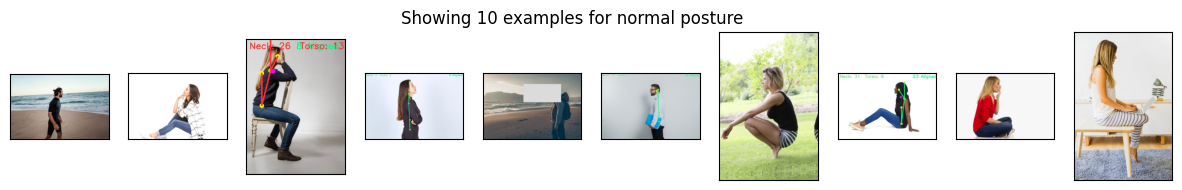

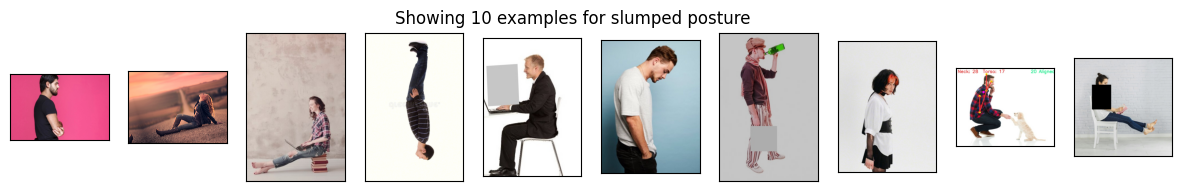

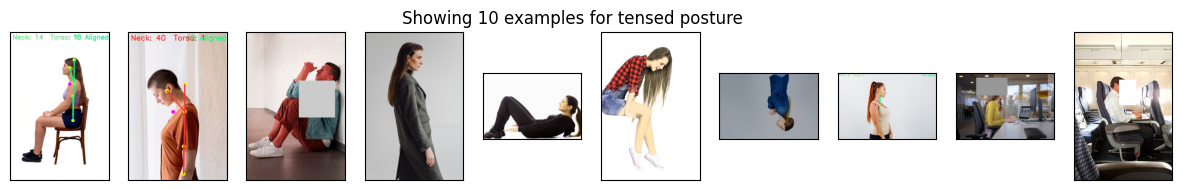

In [15]:
NUM_EXAMPLES = 10

# Setting fallback image source for visualization if image_path is not defined
if "image_path" not in globals() or image_path is None:
    image_path = TRAIN_DATA_PATH

# Resolving the first available image directory to avoid stale non-existing paths
image_candidates = [
    Path(image_path),
    Path(TRAIN_DATA_PATH) if "TRAIN_DATA_PATH" in globals() else None,
    Path(TRAIN_DATA_PATH_ORIGINAL) if "TRAIN_DATA_PATH_ORIGINAL" in globals() else None,
    DATA_ROOT / "images" / "rebalanced_overlay" if "DATA_ROOT" in globals() else None,
]
active_image_path = next(
    (p for p in image_candidates if p is not None and p.exists() and p.is_dir()),
    None,
 )

if active_image_path is None:
    raise FileNotFoundError(
        "No valid image directory found for visualization. "
        f"Checked candidates: {[str(p) for p in image_candidates if p is not None]}"
    )

image_path = active_image_path

# Setting labels from the active image path and aligning stale label state if needed
labels_from_path = sorted(
    [
        entry.name
        for entry in Path(image_path).iterdir()
        if entry.is_dir() and not entry.name.startswith(".")
    ]
)

if "labels" not in globals() or not labels:
    labels = labels_from_path
else:
    missing_label_dirs = [
        label for label in labels if not os.path.isdir(os.path.join(str(image_path), label))
    ]
    if missing_label_dirs:
        print("Detected stale labels for current image_path; using folder labels from image_path.")
        labels = labels_from_path

for label in labels:
    label_dir = os.path.join(str(image_path), label)
    if not os.path.isdir(label_dir):
        print(f"Skipping missing label directory: {label_dir}")
        continue

    # Filtering out hidden files (e.g. .DS_Store) and non-files
    all_files = [
        f
        for f in os.listdir(label_dir)
        if not f.startswith('.') and os.path.isfile(os.path.join(label_dir, f))
    ]

    if not all_files:
        print(f"Skipping label with no images: {label}")
        continue

    example_filenames = all_files[: min(NUM_EXAMPLES, len(all_files))]
    fig, axs = plt.subplots(
        1,
        len(example_filenames),
        figsize=(max(10, len(example_filenames) * 1.5), 2),
    )

    if len(example_filenames) == 1:
        axs = [axs]

    for i, filename in enumerate(example_filenames):
        axs[i].imshow(plt.imread(os.path.join(label_dir, filename)))
        axs[i].get_xaxis().set_visible(False)
        axs[i].get_yaxis().set_visible(False)

    fig.suptitle(f"Showing {len(example_filenames)} examples for {label}")

plt.show()

### Creating dataset

Training data for machine learning can be large, consisting of hundreds or thousands of files which typically do not fit into available memory. You must also split it into groups for different uses: training, testing, and validation. For these reasons, Model Maker uses a `Dataset` class to organize training data and feed it to the retraining process.

To create a dataset, use the `Dataset.from_folder` method to load the data located at `image_path` and split it into training, testing, and validation groups:

In [16]:
def clean_dataset_files(root_dir):
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
    removed_hidden = 0
    removed_non_image = 0
    removed_corrupt = 0
    kept_images = []

    if root_dir is None:
        return kept_images, removed_hidden, removed_non_image, removed_corrupt

    for current_root, _, files in os.walk(root_dir):
        for filename in files:
            file_path = os.path.join(current_root, filename)
            ext = os.path.splitext(filename)[1].lower()
            if filename.startswith('.'):
                try:
                    os.remove(file_path)
                    removed_hidden += 1
                except OSError:
                    pass
            elif ext not in valid_ext:
                try:
                    os.remove(file_path)
                    removed_non_image += 1
                except OSError:
                    pass
            else:
                # Validate image with TensorFlow decoder to mirror training pipeline behavior
                try:
                    if os.path.getsize(file_path) <= 0:
                        raise ValueError("Image size is zero")
                    raw = tf.io.read_file(file_path)
                    _ = tf.io.decode_image(raw, channels=3, expand_animations=False)
                    kept_images.append(file_path)
                except Exception:
                    try:
                        os.remove(file_path)
                        removed_corrupt += 1
                    except OSError:
                        pass

    return kept_images, removed_hidden, removed_non_image, removed_corrupt


def count_images_per_class_from_dir(root_dir):
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
    class_counts = {}
    if root_dir is None or not os.path.isdir(root_dir):
        return class_counts

    for class_name in sorted(os.listdir(root_dir)):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        count = 0
        for filename in os.listdir(class_dir):
            if filename.startswith('.'):
                continue
            file_path = os.path.join(class_dir, filename)
            ext = os.path.splitext(filename)[1].lower()
            if os.path.isfile(file_path) and ext in valid_ext:
                count += 1
        class_counts[class_name] = count

    return class_counts


def count_labels_in_dataset(dataset_obj, class_names):
    class_counts = {name: 0 for name in class_names}
    tf_dataset = dataset_obj.gen_tf_dataset(batch_size=1, is_training=False)

    for _, labels_batch in tf_dataset:
        labels_np = labels_batch.numpy() if hasattr(labels_batch, "numpy") else labels_batch
        labels_np = labels_np.reshape(labels_np.shape[0], -1)
        label_ids = labels_np.argmax(axis=1) if labels_np.shape[1] > 1 else labels_np.reshape(-1).astype(int)

        for label_id in label_ids:
            idx = int(label_id)
            if 0 <= idx < len(class_names):
                class_counts[class_names[idx]] += 1

    return class_counts


def print_class_counts(title, class_counts):
    total = sum(class_counts.values())
    print(f"{title} class counts (total={total}):")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count}")
    print()


train_images, train_hidden, train_non_image, train_corrupt = clean_dataset_files(str(TRAIN_DATA_PATH))
print(
    f"Train images: {len(train_images)}, removed hidden: {train_hidden}, "
    f"removed non-image: {train_non_image}, removed corrupt: {train_corrupt}"
)

train_class_counts = count_images_per_class_from_dir(str(TRAIN_DATA_PATH))
print_class_counts("Train source", train_class_counts)

validation_path_is_usable = False
if VALIDATION_DATA_PATH is not None:
    validation_path_obj = Path(VALIDATION_DATA_PATH)
    val_exists = validation_path_obj.exists() and validation_path_obj.is_dir()
    val_source_class_counts = count_images_per_class_from_dir(str(validation_path_obj)) if val_exists else {}
    val_total_images = sum(val_source_class_counts.values()) if val_source_class_counts else 0
    validation_path_is_usable = val_exists and val_total_images > 0

    print(f"Configured validation path: {validation_path_obj}")
    print(f"Validation path exists: {val_exists}")
    print(f"Validation source image total: {val_total_images}")

if validation_path_is_usable:
    val_images, val_hidden, val_non_image, val_corrupt = clean_dataset_files(str(VALIDATION_DATA_PATH))
    print(
        f"Validation images: {len(val_images)}, removed hidden: {val_hidden}, "
        f"removed non-image: {val_non_image}, removed corrupt: {val_corrupt}"
    )

    val_source_class_counts = count_images_per_class_from_dir(str(VALIDATION_DATA_PATH))
    print_class_counts("Validation source", val_source_class_counts)

    train_data = image_classifier.Dataset.from_folder(str(TRAIN_DATA_PATH))
    validation_full = image_classifier.Dataset.from_folder(str(VALIDATION_DATA_PATH))
    test_data, validation_data = validation_full.split(0.5)
    print("Using external validation folder for validation/test split.")

else:
    if VALIDATION_DATA_PATH is not None:
        print(
            "VALIDATION_DATA_PATH is set but not usable (missing/empty). "
            "Falling back to splitting TRAIN_DATA_PATH into train/validation/test."
        )

    validation_split = float(
        globals().get("VALIDATION_DATA_SPLIT", globals().get("VALIDATION_DATA_SLIT", 0.15))
    )
    if validation_split <= 0.0 or validation_split >= 0.5:
        raise ValueError(
            f"VALIDATION_DATA_SLIT/VALIDATION_DATA_SPLIT must be in (0, 0.5). Got {validation_split}"
        )

    holdout_ratio = validation_split * 2.0
    print(
        "VALIDATION_DATA_PATH is None; creating validation and test splits randomly from TRAIN_DATA_PATH. "
        f"Each split ratio={validation_split:.4f} (combined holdout={holdout_ratio:.4f})."
    )

    full_data = image_classifier.Dataset.from_folder(str(TRAIN_DATA_PATH))
    train_data, holdout_data = full_data.split(1.0 - holdout_ratio)
    test_data, validation_data = holdout_data.split(0.5)
    validation_full = holdout_data
    val_source_class_counts = {}

if train_class_counts:
    ordered_class_names = list(train_class_counts.keys())
elif val_source_class_counts:
    ordered_class_names = list(val_source_class_counts.keys())
else:
    ordered_class_names = sorted(labels) if "labels" in globals() and labels else []

if ordered_class_names:
    train_split_class_counts = count_labels_in_dataset(train_data, ordered_class_names)
    validation_class_counts = count_labels_in_dataset(validation_data, ordered_class_names)
    test_class_counts = count_labels_in_dataset(test_data, ordered_class_names)
    print_class_counts("Train split", train_split_class_counts)
    print_class_counts("Validation split", validation_class_counts)
    print_class_counts("Test split", test_class_counts)
else:
    print("No class names available to compute train/validation/test split class counts.")

Train images: 1988, removed hidden: 0, removed non-image: 0, removed corrupt: 0
Train source class counts (total=1988):
  normal posture: 666
  slumped posture: 671
  tensed posture: 651

VALIDATION_DATA_PATH is None; creating validation and test splits randomly from TRAIN_DATA_PATH. Each split ratio=0.1000 (combined holdout=0.2000).
Train split class counts (total=1590):
  normal posture: 534
  slumped posture: 540
  tensed posture: 516

Validation split class counts (total=199):
  normal posture: 69
  slumped posture: 69
  tensed posture: 61

Test split class counts (total=199):
  normal posture: 63
  slumped posture: 62
  tensed posture: 74



## Retraining model

Once you have completed preparing your data, you can begin retraining a model to build a new classification layer that can recognize the items types, or classes, defined by your training data. This type of model modification is called [transfer learning](https://www.wikipedia.org/wiki/Transfer_learning). The instructions below use the data prepared in the previous section to retrain an image classification model to recognize different types of flowers.

**Note:** For this type of model, the retraining process causes the model to forget any classes it was previously able to recognize. Once the retraining is complete, the new model can *only* recognize classes trained from the new dataset.

### Set retraining options

There are a few required settings to run a retraining aside from your training dataset: output directory for the model and the model architecture. Use `HParams` object `export_dir` parameter to specify a model output directory. Use the `SupportedModels` class to specify the model architecture. The image classifier solution supports the following model architectures:

- `EfficientNet-Lite0` = EFFICIENTNET_LITE0
- `EfficientNet-Lite2` = EFFICIENTNET_LITE2
- `EfficientNet-Lite4` = EFFICIENTNET_LITE4
- `MobileNet-V2` = MOBILENET_V2

To set the required parameters, use the following code:

In [38]:
# Setting model architecture with a simple normalized lookup
MODEL_ARCHITECTURE = "MOBILENET_V2"
normalized_architecture = MODEL_ARCHITECTURE.strip().upper().replace("-", "_").replace(" ", "_")

if not hasattr(image_classifier.SupportedModels, normalized_architecture):
    raise ValueError(
        f"Unsupported MODEL_ARCHITECTURE: {MODEL_ARCHITECTURE}. "
        f"Supported options are: {[m.name for m in image_classifier.SupportedModels]}"
    )

spec = getattr(image_classifier.SupportedModels, normalized_architecture)

# Setting explicit batch size for reproducible steps-per-epoch
BATCH_SIZE = 16

# Setting epoch numbers
EPOCH_NUMBER = 80

# Setting a unique export directory per architecture and run to avoid stale checkpoint restores
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
model_export_dir = OUTPUT_MODEL_PATH / spec.name.lower() / run_id
model_export_dir.mkdir(parents=True, exist_ok=True)

hparams = image_classifier.HParams(
    epochs=EPOCH_NUMBER,
    batch_size=BATCH_SIZE,
    export_dir=str(model_export_dir),
)
options = image_classifier.ImageClassifierOptions(
    supported_model=spec,
    hparams=hparams,
)

print(f"Training spec: {spec.name}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Run export dir: {model_export_dir}")

Training spec: MOBILENET_V2
Batch size: 16
Run export dir: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/models/mobilenet_v2/20260421_130248


This example code uses MobileNetV2 model architecture, which you can learn more about from the  [MobileNetV2](https://arxiv.org/abs/1801.04381) research paper. The retraining process has many additional options, however most of them are set for you automatically. You can learn about these optional parameters in the [Retraining parameters](#retraining_parameters) section.

### Running retraining

With your training dataset and retraining options prepared, you are ready to start the retraining process. This process is resource intensive and can take a few minutes to a few hours depending on your available compute resources. Using a Google Colab environment with standard CPU processing, the example retraining below takes about 20 minutes to train on approximately 4000 images. You can typically decrease your training time by using GPU processors.

To begin the retraining process, use the `create()` method with dataset and options you previously defined:

In [39]:
tf.keras.backend.clear_session()

def _create_model_compat(self):
    print(f"Loading TF-Hub backbone (one-time download/cache): {self._model_spec.uri}")
    module_layer = hub.KerasLayer(
        handle=self._model_spec.uri,
        trainable=self._hparams.do_fine_tuning,
    )

    # Build using the legacy tf_keras to maintain compatibility with hub.KerasLayer
    self._model = tf_keras.Sequential([
        tf_keras.Input(shape=tuple(self._model_spec.input_image_shape) + (3,)),
        module_layer,
        tf_keras.layers.Dropout(rate=self._model_options.dropout_rate),
        tf_keras.layers.Dense(
            units=self._num_classes,
            activation="softmax",
            kernel_regularizer=tf_keras.regularizers.L1L2(
                l1=self._hparams.l1_regularizer,
                l2=self._hparams.l2_regularizer,
            ),
        )
    ])
    print(self._model.summary())

# Unconditionally apply the patch to overwrite any previous failed patches in the kernel state
image_classifier_module.ImageClassifier._create_model = _create_model_compat

# Patch for Keras 3 missing 'experimental' module used by MediaPipe Model Maker
if not hasattr(tf.keras, "experimental"):
    tf.keras.experimental = types.SimpleNamespace()
if not hasattr(tf.keras.experimental, "CosineDecay"):
    tf.keras.experimental.CosineDecay = tf.keras.optimizers.schedules.CosineDecay

# Patch for callback hook compatibility expected by tf_keras training loops
def _ensure_batch_hook_compat(callbacks_module):
    callback_cls = getattr(callbacks_module, "Callback", None)
    if callback_cls is not None:
        if not hasattr(callback_cls, "_implements_train_batch_hooks"):
            def _implements_train_batch_hooks(self):
                return False
            callback_cls._implements_train_batch_hooks = _implements_train_batch_hooks

        if not hasattr(callback_cls, "_implements_test_batch_hooks"):
            def _implements_test_batch_hooks(self):
                return False
            callback_cls._implements_test_batch_hooks = _implements_test_batch_hooks

        if not hasattr(callback_cls, "_implements_predict_batch_hooks"):
            def _implements_predict_batch_hooks(self):
                return False
            callback_cls._implements_predict_batch_hooks = _implements_predict_batch_hooks

    tensorboard_cls = getattr(callbacks_module, "TensorBoard", None)
    if tensorboard_cls is not None:
        if not hasattr(tensorboard_cls, "_implements_train_batch_hooks"):
            def _implements_train_batch_hooks(self):
                return False
            tensorboard_cls._implements_train_batch_hooks = _implements_train_batch_hooks

        if not hasattr(tensorboard_cls, "_implements_test_batch_hooks"):
            def _implements_test_batch_hooks(self):
                return False
            tensorboard_cls._implements_test_batch_hooks = _implements_test_batch_hooks

        if not hasattr(tensorboard_cls, "_implements_predict_batch_hooks"):
            def _implements_predict_batch_hooks(self):
                return False
            tensorboard_cls._implements_predict_batch_hooks = _implements_predict_batch_hooks

_ensure_batch_hook_compat(tf.keras.callbacks)
_ensure_batch_hook_compat(tf_keras.callbacks)
_ensure_batch_hook_compat(keras.callbacks)

# Restore the RMSprop optimizer from legacy Keras to override the macOS optimization workaround
tf.keras.optimizers.RMSprop = tf_keras.optimizers.RMSprop

# Patch for WarmUp missing Keras 3 LearningRateSchedule inheritance
if not getattr(model_util.WarmUp, "_is_patched", False):
    _OriginalWarmUp = model_util.WarmUp
    class WarmUpCompat(_OriginalWarmUp, tf_keras.optimizers.schedules.LearningRateSchedule):
        _is_patched = True
        def __init__(self, initial_learning_rate, decay_schedule_fn, warmup_steps, name=None):
            tf_keras.optimizers.schedules.LearningRateSchedule.__init__(self)
            self.initial_learning_rate = initial_learning_rate
            self.warmup_steps = warmup_steps
            self.decay_schedule_fn = decay_schedule_fn
            self.name = name
        
        def __call__(self, step):
            return _OriginalWarmUp.__call__(self, step)

    model_util.WarmUp = WarmUpCompat

# Creating fallback training options if the retraining-options cell has not been executed
if "options" not in globals():
    spec = image_classifier.SupportedModels.EFFICIENTNET_LITE2
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_export_dir = OUTPUT_MODEL_PATH / spec.name.lower() / run_id
    model_export_dir.mkdir(parents=True, exist_ok=True)
    fallback_batch_size = int(globals().get("BATCH_SIZE", 16))
    hparams = image_classifier.HParams(
        epochs=10,
        batch_size=fallback_batch_size,
        export_dir=str(model_export_dir),
    )
    options = image_classifier.ImageClassifierOptions(
        supported_model=spec,
        hparams=hparams,
    )
    print(f"Auto-created options in Cell 21 with spec: {spec.name}")
    print(f"Auto-created export dir: {model_export_dir}")
    print(f"Auto-created batch size: {fallback_batch_size}")

effective_batch_size = getattr(getattr(options, "hparams", None), "batch_size", "unknown")
print(f"Starting training with batch size: {effective_batch_size}")
print("Preparing TF-Hub model. First run can take several minutes while downloading.")
_hub_logger = logging.getLogger("tensorflow_hub")
_hub_prev_level = _hub_logger.level
_hub_logger.setLevel(logging.INFO)

tf.keras.backend.clear_session()
try:
    model = image_classifier.ImageClassifier.create(
        train_data=train_data,
        validation_data=validation_data,
        options=options,
    )
finally:
    _hub_logger.setLevel(_hub_prev_level)
print("Model training call finished.")

Starting training with batch size: 16
Preparing TF-Hub model. First run can take several minutes while downloading.
Loading TF-Hub backbone (one-time download/cache): https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 2261827 (8.63 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________
None
Epoch 1/80
99/99 [=======================

## Export model

After retraining a model, you must export it to Tensorflow Lite model format to use it with the MediaPipe in your application. The export process generates required model metadata, as well as a classification label file.

To export the retrained model for use in your application, use the following command:

In [40]:
model.export_model()

W0000 00:00:1776770493.796985   93374 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776770493.797264   93374 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


## Model tuning

You can use the MediaPipe Model Maker tool to further improve and adjust the  model retraining with configuation options and performance techniques such as data quantization. *These steps are optional.* Model Maker uses reasonable default settings for all of the training configuration parameters, but if you want to further tune the model retraining, the instructions below describe the available options.

### Retraining parameters

You can further customize how the retraining process runs to adjust training time and potentially increase the retrained model's performance. *These parameters are optional*. Use the `ImageClassifierModelOptions` class and the `HParams` class to set these additional options.

Use the `ImageClassifierModelOptions` class parameters to customize the existing model. It has the following customizable parameter that affects model accuracy:
* `dropout_rate`: The fraction of the input units to drop. Used in dropout layer. Defaults to 0.05.

Use the `HParams` class to customize other parameters related to training and saving the model:

* `learning_rate`: The learning rate to use for gradient descent training. Defaults to 0.001.
* `batch_size`: Batch size for training. Defaults to 2.
* `epochs`: Number of training iterations over the dataset. Defaults to 10.
* `steps_per_epoch`: An optional integer that indicates the number of training steps per epoch. If not set, the training pipeline calculates the default steps per epoch as the training dataset size divided by batch size.
* `shuffle`: True if the dataset is shuffled before training. Defaults to False.
* `do_fine_tuning`: If true, the base module is trained together with the classification layer on top. This defaults to False, which means only the classification layer is trained and pre-trained weights for the base module are frozen.
* `l1_regularizer`: A regularizer that applies a L1 regularization penalty. Defaults to 0.0.
* `l2_regularizer`: A regularizer that applies a L2 regularization penalty. Defaults to 0.0001.
* `label_smoothing`: Amount of label smoothing to apply. See [`tf.keras.losses`](https://www.tensorflow.org/api_docs/python/tf/keras/losses) for more details. Defaults to 0.1.
* `do_data_augmentation`: Whether or not the training dataset is augmented by applying random transformations such as cropping, flipping, etc. See [utils.image_preprocessing](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image) for details. Defaults to True.
* `decay_samples`: Number of training samples used to calculate the decay steps and create the training optimizer. Defaults to 2,560,000.
* `warmup_epochs`: Number of warmup steps for a linear increasing warmup schedule on the learning rate. Used to set up warmup schedule by `model_util.WarmUp`. Defaults to 2.



For more information on the general performance of the supported models, refer to the [Performance benchmarks](#performance_benchmarks) section.

### Model quantization

Post-training model quantization is a model modification technique that can reduce the model size and improve the speed of predictions with only a relatively minor decrease in accuracy. This approach reduces the size of the data processed by the model, for example by transforming 32-bit floating point numbers to 8-bit integers. This technique is widely used to further optimize models after the training process.

This section of the guide explains how to apply quantization to your retrained model. This optimization must be done as part of the Model Maker model export process, and cannot be performed on an exported model. The following example demonstrates how to use this approach to apply `int8` quantization to a retrained model. For more information on post-training quantization, see the [TensorFlow Lite](https://www.tensorflow.org/lite/performance/post_training_quantization) documentation.

Define a `QuantizationConfig` object using the `for_int8()` class method. This configuration modifies a trained model to use 8-bit integers instead of larger data types, such as 32-bit floating point numbers. You can further customize the quantization process by setting additional parameters for the `QuantizationConfig` class.

In [41]:
quantization_candidates = []

# Prefer int8 first (highest compression), but keep compatibility fallbacks
quantization_candidates.append(("int8", quantization.QuantizationConfig.for_int8(train_data)))

if hasattr(quantization.QuantizationConfig, "for_float16"):
    quantization_candidates.append(("float16", quantization.QuantizationConfig.for_float16()))

if hasattr(quantization.QuantizationConfig, "dynamic"):
    quantization_candidates.append(("dynamic", quantization.QuantizationConfig.dynamic()))

print("Quantization candidates:", [name for name, _ in quantization_candidates])

Quantization candidates: ['int8', 'float16']


The `for_int8()` method requires a representative dataset, while the `dynamic()` and `for_float16()` quantization methods do not. The quantization process uses the representative dataset to perform model modification and you typically use your existing training dataset for this purpose. For more information on the process and options, see the TensorFlow Lite [Post-training quantization](https://www.tensorflow.org/lite/performance/post_training_quantization) guide.

Export the model using the additional `quantization_config` object to apply post-training quantization:

In [42]:
exported_quant_model = None
last_error = None

for quant_name, quantization_config in quantization_candidates:
    try:
        output_name = f"model_{quant_name}.tflite"
        model.export_model(
            model_name=output_name,
            quantization_config=quantization_config,
        )
        exported_quant_model = output_name
        print(f"Exported quantized model with {quant_name}: {output_name}")
        break
    except TypeError as exc:
        last_error = exc
        print(f"Skipping {quant_name} quantization due to TypeError: {exc}")
    except Exception as exc:
        last_error = exc
        print(f"Skipping {quant_name} quantization due to error: {exc}")

if exported_quant_model is None:
    raise RuntimeError(
        f"Failed to export any quantized model. Last error: {last_error}"
    )

W0000 00:00:1776770505.466022   93374 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776770505.466038   93374 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Exported quantized model with int8: model_int8.tflite


After running this command, you should have a new `model_int8.tflite` or `model_float16.tflite` model file. This new, quantized model should be significantly smaller than the `model.tflite` file.

### Evaluating the model (with Class-Wise Analysis)

This section evaluates the trained model across all classes (`normal`, `slumped`, `tensed`) using:

- Confusion matrix (rows=true, columns=predicted)
- Per-class precision, recall, and F1-score
- Pairwise confusion counts:
  - `normal` vs `slumped`
  - `normal` vs `tensed`
  - `slumped` vs `tensed`

Run the next cell after model training and exports.

Model architecture: MOBILENET_V2
Training batch size: 16
Epoch number: 80
Model file: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/models/mobilenet_v2/20260421_130248/model.tflite
Quantized model (int8) file: /Users/ben/Documents/Studies/Data Science for Health and Social Care (MSc.)/Dissertation/Project/dissertation-movement-analysis/data/models/mobilenet_v2/20260421_130248/model_int8.tflite
Train split class counts (total=1890):
  normal posture: 630
  slumped posture: 651
  tensed posture: 609

Validation split class counts (total=199):
  normal posture: 69
  slumped posture: 69
  tensed posture: 61

Test split class counts (total=199):
  normal posture: 63
  slumped posture: 62
  tensed posture: 74


Prediction-derived overall accuracy: 0.3065
Model evaluate() loss/accuracy on dataset_obj: 0.736599/0.748744

Analysis batch size: 1

Confusion matrix (rows=true, cols=pred):
[[24 21 18]
 [26 20 16]

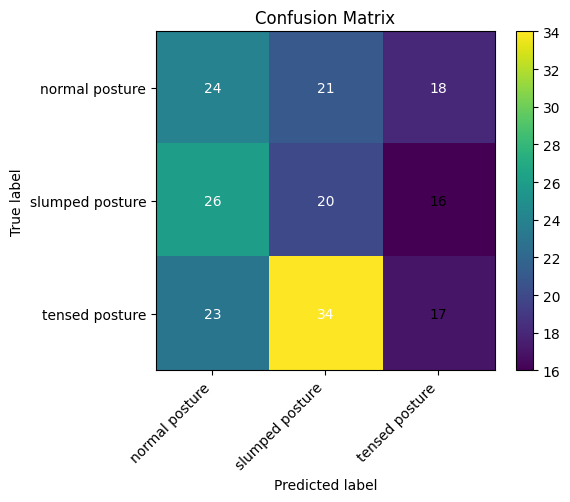

Pairwise confusion counts:
normal -> slumped: 21 | slumped -> normal: 26
normal -> tensed:  18 | tensed  -> normal: 23
slumped -> tensed: 16 | tensed  -> slumped: 34


In [43]:
try:
    from sklearn.metrics import classification_report, confusion_matrix
except ImportError as exc:
    raise ImportError(
        "scikit-learn is required for class-wise analysis. Install it with `%pip install scikit-learn`."
    ) from exc

# Setting class-wise analysis to always use the current in-memory trained model
MODEL_FILE = None

# Setting batch size to 1 avoids shape-collision when source images have different resolutions.
ANALYSIS_BATCH_SIZE = 1
MIN_VALID_QUANT_SCALE = 1e-12


def to_tf_dataset(dataset_obj, batch_size=1):
    """Return a tf.data.Dataset from MediaPipe Model Maker Dataset or pass through tf.data.Dataset."""
    if isinstance(dataset_obj, tf.data.Dataset):
        return dataset_obj

    if not hasattr(dataset_obj, "gen_tf_dataset"):
        raise TypeError("test_data does not expose gen_tf_dataset and is not a tf.data.Dataset")

    fn = dataset_obj.gen_tf_dataset
    call_attempts = [
        {"batch_size": batch_size, "is_training": False},
        {"is_training": False, "batch_size": batch_size},
        {"batch_size": batch_size},
        {},
    ]

    last_error = None
    for kwargs in call_attempts:
        try:
            sig = inspect.signature(fn)
            accepted = {k: v for k, v in kwargs.items() if k in sig.parameters}
            return fn(**accepted)
        except Exception as exc:
            last_error = exc
            continue

    raise RuntimeError(f"Could not create tf dataset from test_data: {last_error}")


def _iter_samples(dataset_obj, batch_size=1):
    ds = to_tf_dataset(dataset_obj, batch_size=batch_size)
    for batch in ds:
        if not isinstance(batch, (tuple, list)) or len(batch) < 2:
            raise ValueError("Expected dataset batch to contain features and labels")

        x_batch, y_batch = batch[0], batch[1]
        x_np = x_batch.numpy() if hasattr(x_batch, "numpy") else np.asarray(x_batch)
        y_np = y_batch.numpy() if hasattr(y_batch, "numpy") else np.asarray(y_batch)

        if y_np.ndim > 1:
            y_np = np.argmax(y_np, axis=1)
        else:
            y_np = y_np.astype(np.int64).reshape(-1)

        for i in range(x_np.shape[0]):
            sample = x_np[i : i + 1]
            label = int(y_np[i])
            yield sample, label


def _resize_for_model(sample, expected_hw):
    h, w = expected_hw
    if h is None or w is None:
        return sample

    if sample.shape[1] == h and sample.shape[2] == w:
        return sample

    resized = tf.image.resize(sample, [h, w], method="bilinear")
    return resized.numpy()


def _quantize_input(sample, input_dtype, quantization):
    if np.issubdtype(input_dtype, np.floating):
        return sample.astype(input_dtype)

    scale, zero_point = quantization
    if scale is None or zero_point is None or scale <= MIN_VALID_QUANT_SCALE:
        return sample.astype(input_dtype)

    quantized = np.round(sample / scale + zero_point)
    dtype_info = np.iinfo(input_dtype)
    quantized = np.clip(quantized, dtype_info.min, dtype_info.max)
    return quantized.astype(input_dtype)


def _dequantize_output(output_tensor, output_dtype, quantization):
    if np.issubdtype(output_dtype, np.floating):
        return output_tensor.astype(np.float32)

    scale, zero_point = quantization
    if scale is None or zero_point is None or scale <= MIN_VALID_QUANT_SCALE:
        return output_tensor.astype(np.float32)

    return (output_tensor.astype(np.float32) - zero_point) * scale


def _predict_with_tflite_samples(model_path, samples):
    interpreter = tf.lite.Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_shape = list(input_details["shape"])
    expected_h = int(input_shape[1]) if len(input_shape) >= 3 and int(input_shape[1]) > 0 else None
    expected_w = int(input_shape[2]) if len(input_shape) >= 3 and int(input_shape[2]) > 0 else None
    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]
    input_quantization = input_details.get("quantization", (0.0, 0))
    output_quantization = output_details.get("quantization", (0.0, 0))

    y_true_all = []
    y_pred_all = []

    for sample, label in samples:
        sample = _resize_for_model(sample, (expected_h, expected_w)).astype(np.float32)
        sample = _quantize_input(sample, input_dtype, input_quantization)

        interpreter.set_tensor(input_details["index"], sample)
        interpreter.invoke()

        raw_output = interpreter.get_tensor(output_details["index"])
        probs = _dequantize_output(raw_output, output_dtype, output_quantization)
        pred = int(np.argmax(probs, axis=1)[0])

        y_true_all.append(label)
        y_pred_all.append(pred)

    return np.array(y_true_all, dtype=np.int64), np.array(y_pred_all, dtype=np.int64)


def _predict_with_trained_model_samples(trained_model, samples):
    y_true_all = []
    y_pred_all = []

    expected_h = None
    expected_w = None
    input_shape = trained_model._model.input_shape
    if isinstance(input_shape, tuple) and len(input_shape) >= 3:
        expected_h = input_shape[1]
        expected_w = input_shape[2]

    for sample, label in samples:
        sample = _resize_for_model(sample, (expected_h, expected_w))
        probs = trained_model._model.predict(sample, verbose=0)
        pred = int(np.argmax(probs, axis=1)[0])

        y_true_all.append(label)
        y_pred_all.append(pred)

    return np.array(y_true_all, dtype=np.int64), np.array(y_pred_all, dtype=np.int64)


def _manual_added_counts_from_state():
    manual_config = globals().get("AUGMENT_CLASS_MANUAL", None)
    if manual_config is None:
        return {}

    summary_obj = globals().get("manual_summary", None)
    if not isinstance(summary_obj, dict):
        return {}

    class_added = {}
    for class_name, stats in summary_obj.items():
        if not isinstance(stats, dict):
            continue
        try:
            added = int(stats.get("added", 0))
        except (TypeError, ValueError):
            added = 0
        if added > 0:
            class_added[class_name] = class_added.get(class_name, 0) + added

    return class_added


def run_classwise_analysis(dataset_obj, class_names=None, batch_size=1, tflite_model_path=None, trained_model=None):
    samples = list(_iter_samples(dataset_obj, batch_size=batch_size))
    if not samples:
        raise RuntimeError("No samples were produced from the test dataset.")

    if tflite_model_path is not None:
        y_true_all, y_pred_all = _predict_with_tflite_samples(tflite_model_path, samples)
    elif trained_model is not None:
        y_true_all, y_pred_all = _predict_with_trained_model_samples(trained_model, samples)
    else:
        raise ValueError("Provide either tflite_model_path or trained_model")

    num_classes = int(max(np.max(y_true_all), np.max(y_pred_all)) + 1)
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]
    class_names = list(class_names)

    if len(class_names) != num_classes:
        class_names = class_names[:num_classes] + [str(i) for i in range(len(class_names), num_classes)]

    labels_idx = list(range(num_classes))
    cm = confusion_matrix(y_true_all, y_pred_all, labels=labels_idx)
    analysis_accuracy = float(np.mean(y_true_all == y_pred_all))

    print(f"Model architecture: {MODEL_ARCHITECTURE}")
    print(f"Training batch size: {BATCH_SIZE}")
    print(f"Epoch number: {EPOCH_NUMBER}")
    print(f"Model file: {model_export_dir}/model.tflite")
    print(f"Quantized model ({quant_name}) file: {model_export_dir}/{output_name}")

    if ordered_class_names:
        train_split_class_counts = count_labels_in_dataset(train_data, ordered_class_names)
        validation_class_counts = count_labels_in_dataset(validation_data, ordered_class_names)
        test_class_counts = count_labels_in_dataset(test_data, ordered_class_names)

        # Adding manually merged image counts into the train split report without changing report text
        manual_added_counts = _manual_added_counts_from_state()
        for class_name, added_count in manual_added_counts.items():
            train_split_class_counts[class_name] = train_split_class_counts.get(class_name, 0) + added_count

        print_class_counts("Train split", train_split_class_counts)
        print_class_counts("Validation split", validation_class_counts)
        print_class_counts("Test split", test_class_counts)
    else:
        print("No class names available to compute train/validation/test split class counts.")
    print("")
    print(f"Prediction-derived overall accuracy: {analysis_accuracy:.4f}")

    if trained_model is not None and tflite_model_path is None and hasattr(trained_model, "evaluate"):
        _eval_capture = io.StringIO()
        with contextlib.redirect_stdout(_eval_capture), contextlib.redirect_stderr(_eval_capture):
            loss, acc = trained_model.evaluate(dataset_obj)
        print(f"Model evaluate() loss/accuracy on dataset_obj: {loss:.6f}/{acc:.6f}")
    print("")
    print(f"Analysis batch size: {batch_size}")
    print("\nConfusion matrix (rows=true, cols=pred):")
    print(cm)

    row_totals = cm.sum(axis=1, keepdims=True)
    cm_row_normalized = np.divide(cm, row_totals, where=row_totals != 0)
    print("\nRow-normalized confusion matrix (recall by class):")
    print(np.round(cm_row_normalized, 4))

    per_class_support = cm.sum(axis=1)
    print("\nPer-class support:")
    for class_name, support in zip(class_names, per_class_support):
        print(f"  {class_name}: {int(support)}")

    per_class_recall = np.divide(
        np.diag(cm),
        per_class_support,
        out=np.zeros_like(per_class_support, dtype=np.float64),
        where=per_class_support != 0,
    )
    balanced_accuracy = float(np.mean(per_class_recall))
    print(f"Balanced accuracy (macro recall): {balanced_accuracy:.4f}")
    print("\nClassification report:")
    print(
        classification_report(
            y_true_all,
            y_pred_all,
            labels=labels_idx,
            target_names=class_names,
            digits=4,
            zero_division=0,
        )
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(num_classes), class_names)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    threshold = cm.max() / 2 if cm.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
            )
    plt.tight_layout()
    plt.show()

    if len(class_names) >= 3:
        normalized_to_idx = {}
        for i, name in enumerate(class_names):
            normalized_name = name.strip().lower().replace(" posture", "")
            normalized_to_idx[normalized_name] = i

        required = ["normal", "slumped", "tensed"]
        if all(name in normalized_to_idx for name in required):
            n = normalized_to_idx["normal"]
            s = normalized_to_idx["slumped"]
            t = normalized_to_idx["tensed"]
            print("Pairwise confusion counts:")
            print(f"normal -> slumped: {cm[n, s]} | slumped -> normal: {cm[s, n]}")
            print(f"normal -> tensed:  {cm[n, t]} | tensed  -> normal: {cm[t, n]}")
            print(f"slumped -> tensed: {cm[s, t]} | tensed  -> slumped: {cm[t, s]}")
        else:
            print("Pairwise confusion counts skipped: expected class names normal/slumped/tensed not found.")

    return cm, y_true_all, y_pred_all


ordered_class_names_fallback = globals().get("ordered_class_names")

if hasattr(model, "_label_names") and model._label_names:
    analysis_class_names = list(model._label_names)
elif ordered_class_names_fallback:
    # Setting fallback class order from dataset split preparation when model labels are unavailable.
    analysis_class_names = list(ordered_class_names_fallback)
elif "labels" in globals() and labels:
    analysis_class_names = sorted(labels)
else:
    analysis_class_names = None

cm, y_true, y_pred = run_classwise_analysis(
    dataset_obj=test_data,
    class_names=analysis_class_names,
    batch_size=ANALYSIS_BATCH_SIZE,
    tflite_model_path=None,
    trained_model=model,
)

Accuracy levels between 0.8 and 0.9 are generally considered very good, but your use case requirements may differ. You should also consider how fast the model can produce an inference. Higher accuracy frequently comes at the cost of longer inference times.

**Caution:** While high accuracy of a model is a common goal for machine learning models, you should be cautious of training to a point of [overfitting](https://en.wikipedia.org/wiki/Overfitting), which causes the model to perform extremely well with its training data, but quite poorly on new data.

## Performance benchmarks

Below is a summary of our benchmarking results for the supported model architectures. These models were trained and evaluated on the same flowers dataset as this notebook. When considering the model benchmarking results, there are a few important caveats to keep in mind:
- The test accuracy column reflects models which were trained with the default parameters. To optimize model performance, experiment with different model and retraining parameters in order to obtain the highest test accuracy. Refer to the [Retraining parameters](#retraining_parameters) section for more information on customizing these settings.
- The larger model architectures, such as EfficientNet_Lite4, may not acheive the highest test accuracy on simpler datasets like the flowers dataset used this notebook. Research suggests that these larger model architecture can outperform the others on more complex datasets like ImageNet, for more information, see [EfficientNet paper](https://arxiv.org/pdf/1905.11946.pdf). The ImageNet dataset is more complex, with over a million training images and 1000 classes, while the flowers dataset has only 3670 training images and 5 classses.

<table>
<thead>
<tr>
<th>Model architecture</th>
<th>Test Accuracy</th>
<th>Model Size</th>
<th>CPU 1 Thread Latency(Pixel 6)</th>
<th>GPU Latency(Pixel 6)</th>
<th>EdgeTPULatency(Pixel 6)</th>
</tr>
</thead>
<tbody>
<tr>
<td>MobileNet_V2</td>
<td>85.4%</td>
<td><strong>8.9MB</strong></td>
<td>29.12</td>
<td>77.77</td>
<td>31.14</td>
</tr>
<tr>
<td>EfficientNet_Lite0</td>
<td>91.3%</td>
<td>13.5MB</td>
<td><strong>15.6</strong></td>
<td><strong>9.25</strong></td>
<td><strong>16.72</strong></td>
</tr>
<tr>
<td>EfficientNet_Lite2</td>
<td><strong>91.5%</strong></td>
<td>19.2MB</td>
<td>35.2</td>
<td>13.94</td>
<td>37.52</td>
</tr>
<tr>
<td>EfficientNet_Lite4</td>
<td>90.8%</td>
<td>46.8MB</td>
<td>103.16</td>
<td>23.14</td>
<td>114.67</td>
</tr>
</tbody>
</table>